# Delay Line

Two functions live in `src/python/delay/line.py`:

| Function | Delay type | Interpolation |
| --- | --- | --- |
| `delay_line` | Integer samples only | None — pure sample shift |
| `fractional_delay_line` | Any positive float (or per-sample array) | Lagrange polynomial (order 3 or 4) |

`fractional_delay_line` is the building block for vibrato, chorus, flanger, and Karplus-Strong pitch correction — anywhere the delay must sweep continuously through non-integer positions.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import delay_line, fractional_delay_line
from python.generators import generate_impulse, generate_sine

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1  `delay_line` — integer sample shift

`y[n] = x[n − D]` — the D leading samples are always zero (initial rest).  
Transfer function H(z) = z^(−D): flat magnitude, linear phase (slope = −D).

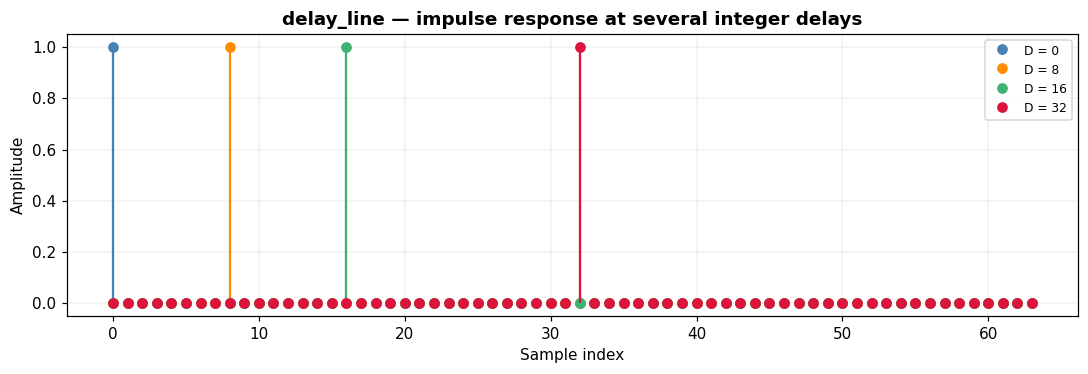

In [2]:
_, imp = generate_impulse(fs=FS, duration=64 / FS)
n = np.arange(len(imp))

DELAYS = [0, 8, 16, 32]
COLORS = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

fig, ax = plt.subplots(figsize=(10, 3.5))
for d, color in zip(DELAYS, COLORS):
    out = delay_line(imp, d)
    ax.stem(n, out, linefmt=color, markerfmt=f'o', basefmt='none',
            label=f'D = {d}', orientation='vertical')
ax.set_title('delay_line — impulse response at several integer delays', fontweight='bold')
ax.set_xlabel('Sample index')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

## 2  `fractional_delay_line` — impulse response at fractional positions

For an integer delay the impulse lands exactly on one sample.  
For a fractional delay the energy is distributed across the stencil, with the weighted centroid at exactly `delay_samples`.

At f = 0.5 (half-sample) the two central weights are equal and the outer negative lobes cancel — the response is symmetric about the half-sample point.

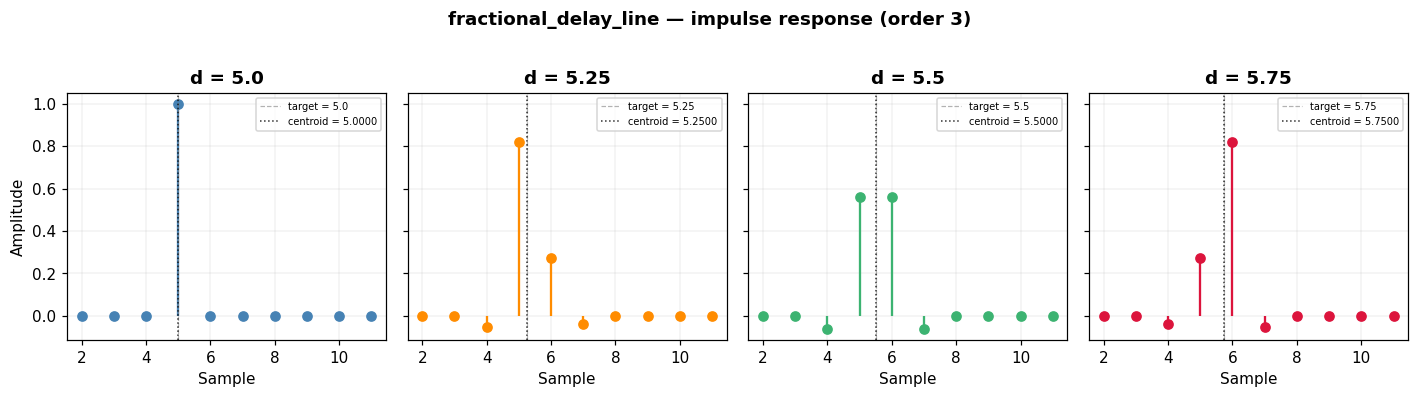

In [3]:
_, imp = generate_impulse(fs=FS, duration=32 / FS)
n = np.arange(len(imp))

FRAC_DELAYS = [5.0, 5.25, 5.5, 5.75]
COLORS = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

fig, axes = plt.subplots(1, len(FRAC_DELAYS), figsize=(13, 3.5), sharey=True)
for ax, d, color in zip(axes, FRAC_DELAYS, COLORS):
    out = fractional_delay_line(imp, d)
    # centre-of-mass sanity check
    com = np.sum(n * out) / np.sum(out)
    ax.stem(n[2:12], out[2:12], linefmt=color, markerfmt='o', basefmt='none')
    ax.axvline(d, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label=f'target = {d}')
    ax.axvline(com, color='black', linewidth=1.0, linestyle=':', alpha=0.8, label=f'centroid = {com:.4f}')
    ax.set_title(f'd = {d}', fontweight='bold')
    ax.set_xlabel('Sample')
    ax.legend(fontsize=6.5)
    ax.grid(True, linewidth=0.3, alpha=0.5)
axes[0].set_ylabel('Amplitude')
fig.suptitle('fractional_delay_line — impulse response (order 3)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3  Order comparison — frequency response

Both orders are all-pass in the low-frequency region.  
Order 4 (5-point) holds magnitude closer to 0 dB at higher frequencies before the Lagrange approximation breaks down near Nyquist.

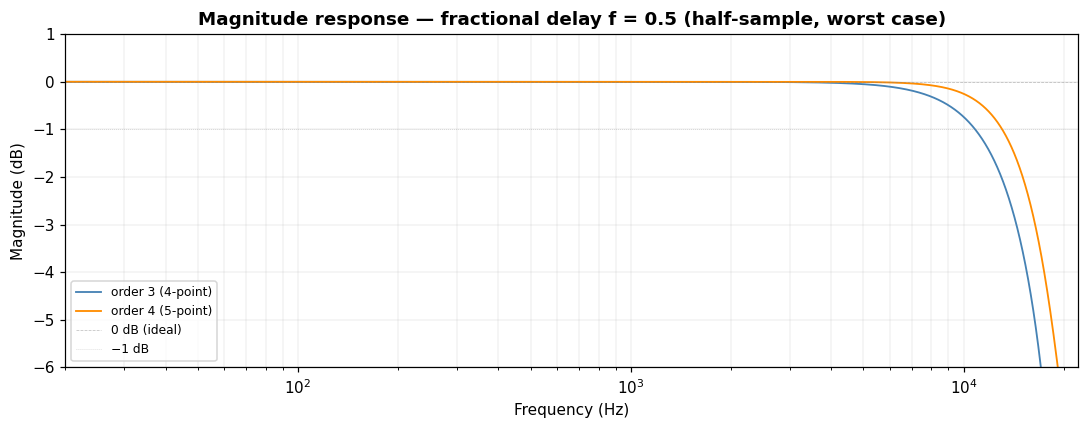

order 3: magnitude > −1 dB up to 10820 Hz  (49.1% of Nyquist)
order 4: magnitude > −1 dB up to 13049 Hz  (59.2% of Nyquist)


In [4]:
N = 8192
_, imp_long = generate_impulse(fs=FS, duration=N / FS)

FRAC = 0.5  # half-sample — worst case for interpolation error

h3 = fractional_delay_line(imp_long, 100 + FRAC, order=3)
h4 = fractional_delay_line(imp_long, 100 + FRAC, order=4)

freqs = np.fft.rfftfreq(N, d=1.0 / FS)
mag3 = 20 * np.log10(np.abs(np.fft.rfft(h3)) + 1e-12)
mag4 = 20 * np.log10(np.abs(np.fft.rfft(h4)) + 1e-12)

mask = freqs > 10
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(freqs[mask], mag3[mask], label='order 3 (4-point)', color='steelblue', linewidth=1.2)
ax.semilogx(freqs[mask], mag4[mask], label='order 4 (5-point)', color='darkorange', linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5, label='0 dB (ideal)')
ax.axhline(-1, color='gray', linewidth=0.5, linestyle=':', alpha=0.4, label='−1 dB')
ax.set_title(f'Magnitude response — fractional delay f = {FRAC} (half-sample, worst case)',
             fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_xlim(20, FS / 2)
ax.set_ylim(-6, 1)
ax.legend(fontsize=8)
ax.grid(True, which='both', linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

# report −1 dB bandwidth for each order
for label, mag in [('order 3', mag3), ('order 4', mag4)]:
    valid = freqs[mask][mag[mask] > -1.0]
    bw = valid[-1] if len(valid) else 0
    print(f'{label}: magnitude > −1 dB up to {bw:.0f} Hz  ({100*bw/(FS/2):.1f}% of Nyquist)')

## 4  Phase response — linear phase confirmed

An ideal fractional delay is a linear-phase all-pass: phase = −2π · f · d/N, where d is the total delay in samples.  
The unwrapped phase of the Lagrange filter should follow this line closely up to the Nyquist cutoff where the approximation degrades.

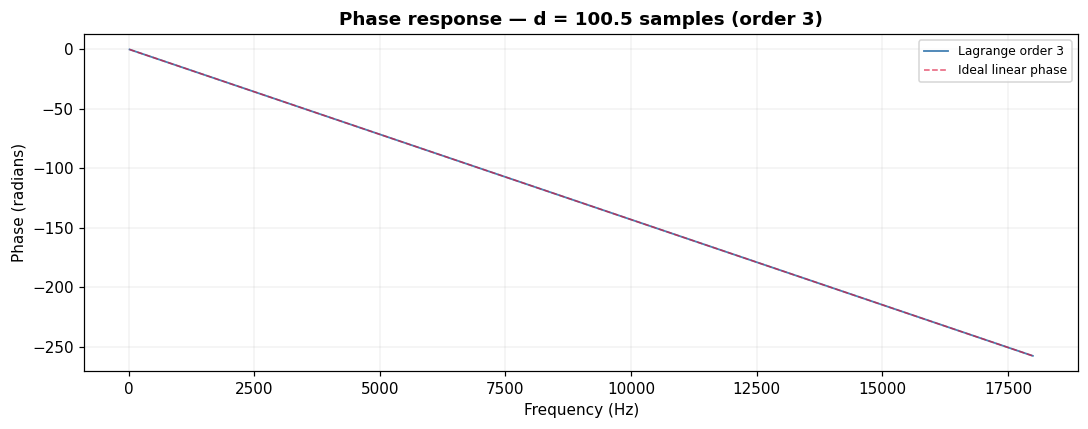

In [5]:
D_TOTAL = 100.5  # 100 integer + 0.5 fractional
h = fractional_delay_line(imp_long, D_TOTAL, order=3)

H = np.fft.rfft(h)
freqs = np.fft.rfftfreq(N, d=1.0 / FS)
phase = np.unwrap(np.angle(H))
ideal = -2 * np.pi * freqs * D_TOTAL / FS

mask = (freqs > 20) & (freqs < 18000)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs[mask], phase[mask], label='Lagrange order 3', color='steelblue', linewidth=1.2)
ax.plot(freqs[mask], ideal[mask], label='Ideal linear phase', color='crimson',
        linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_title(f'Phase response — d = {D_TOTAL} samples (order 3)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Phase (radians)')
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

## 5  Modulated delay — per-sample array form (vibrato)

When `delay_samples` is a 1-D array of length N, each output sample gets its own fractional delay.  
This is how `vibrato` works: a sinusoidal LFO sweeps the read position, creating continuous pitch deviation.

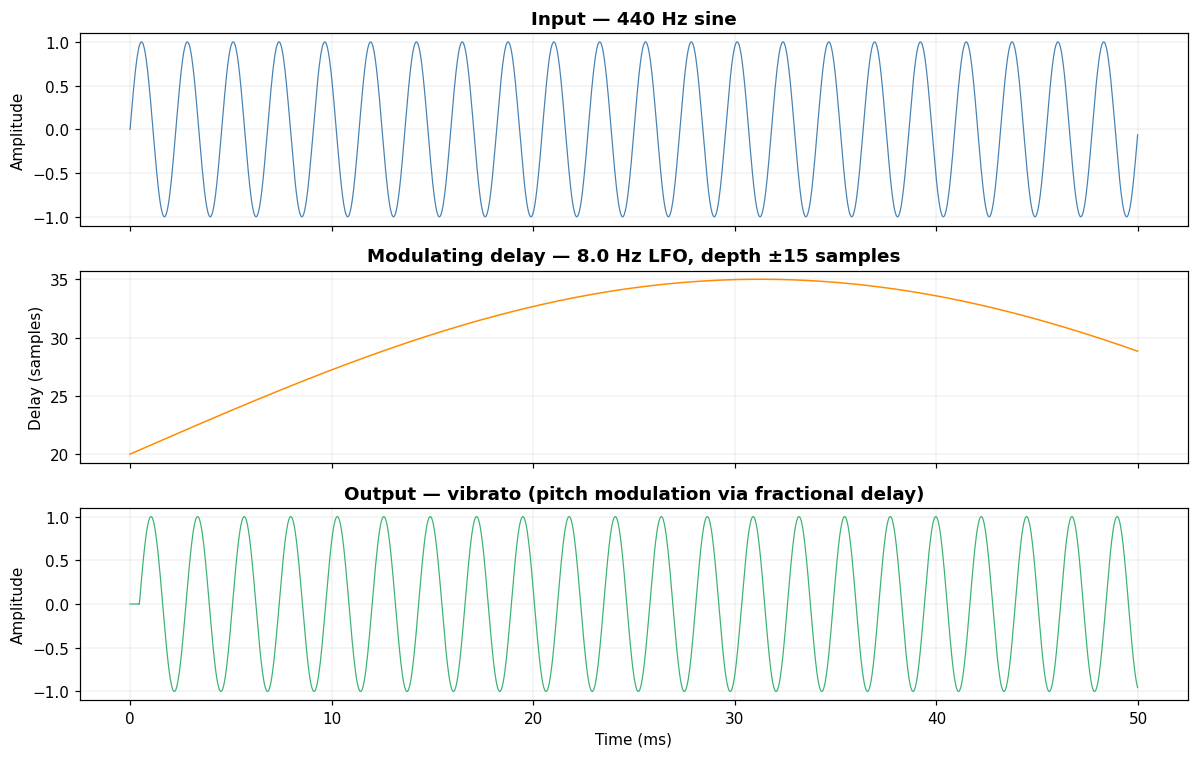

Input  peak amplitude: 1.0000
Output peak amplitude: 1.0000  (should be ≈ 1.0)


In [6]:
_, sig = generate_sine(freq=440.0, fs=FS, duration=0.05)
n_sig = len(sig)
t = np.arange(n_sig) / FS

CENTER = 20      # centre delay in samples
DEPTH  = 15      # modulation depth in samples
RATE   = 8.0     # LFO rate in Hz

delay_arr = CENTER + DEPTH * np.sin(2 * np.pi * RATE * t)
out = fractional_delay_line(sig, delay_arr, order=3)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t * 1000, sig, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Input — 440 Hz sine', fontweight='bold')
axes[0].grid(True, linewidth=0.3, alpha=0.5)

axes[1].plot(t * 1000, delay_arr, color='darkorange', linewidth=1.0)
axes[1].set_ylabel('Delay (samples)')
axes[1].set_title(f'Modulating delay — {RATE} Hz LFO, depth ±{DEPTH} samples', fontweight='bold')
axes[1].grid(True, linewidth=0.3, alpha=0.5)

axes[2].plot(t * 1000, out, color='mediumseagreen', linewidth=0.8)
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('Output — vibrato (pitch modulation via fractional delay)', fontweight='bold')
axes[2].grid(True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

print(f'Input  peak amplitude: {np.max(np.abs(sig)):.4f}')
print(f'Output peak amplitude: {np.max(np.abs(out)):.4f}  (should be ≈ 1.0)')

## 6  Interpolation accuracy — linear vs Lagrange order 3

For a smooth signal (sine wave), we can measure the interpolation error against a reference that shifts the signal by an exact fractional amount in the frequency domain (multiply by the ideal phase factor `exp(−j2πfd/N)`).

In [7]:
N_ACC = 4096
_, sig_long = generate_sine(freq=1000.0, fs=FS, duration=N_ACC / FS)

def fractional_delay_linear(signal, delay):
    """Simple linear (order-1) interpolation for comparison."""
    d_int = int(np.floor(delay))
    f = delay - d_int
    s0 = delay_line(signal, d_int)
    s1 = delay_line(signal, d_int + 1)
    return (1.0 - f) * s0 + f * s1

def ideal_fractional_delay(signal, delay):
    """Reference: fractional delay via frequency-domain phase shift."""
    S = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal))
    S_shifted = S * np.exp(-1j * 2 * np.pi * freqs * delay)
    return np.fft.irfft(S_shifted, n=len(signal))

DELAY = 7.3
ref   = ideal_fractional_delay(sig_long, DELAY)
lin   = fractional_delay_linear(sig_long, DELAY)
lag3  = fractional_delay_line(sig_long, DELAY, order=3)
lag4  = fractional_delay_line(sig_long, DELAY, order=4)

# ignore first and last few samples (transient / edge effects)
sl = slice(20, N_ACC - 20)
for label, out in [('Linear (order 1)', lin), ('Lagrange order 3', lag3), ('Lagrange order 4', lag4)]:
    err = np.max(np.abs(out[sl] - ref[sl]))
    print(f'{label:22s}  max error vs ideal: {err:.2e}')

Linear (order 1)        max error vs ideal: 8.56e-03
Lagrange order 3        max error vs ideal: 6.49e-03
Lagrange order 4        max error vs ideal: 6.48e-03


## Audio Examples

A pure delay shifts the signal in time. Mixing dry and delayed creates an echo. The third example shows how a modulated (time-varying) delay creates a chorus/flanger character even without feedback.


In [8]:
from IPython.display import Audio, display

DUR_A = 2.0
t_a   = np.arange(int(FS * DUR_A)) / FS
saw_a = 0.5 * (2 * ((220.0 * t_a) % 1.0) - 1.0)

D_A   = int(0.2 * FS)        # 200 ms delay
wet_a = delay_line(saw_a, D_A)
echo_a = 0.7 * saw_a + 0.5 * wet_a
echo_a /= np.max(np.abs(echo_a))

print("Dry sawtooth at 220 Hz (no delay)")
display(Audio(saw_a, rate=FS))
print("200 ms delay applied (wet only) — signal starts late")
display(Audio(wet_a, rate=FS))
print("Dry + 200 ms delay mix (50 % wet) — single echo")
display(Audio(echo_a * 0.8, rate=FS))

Dry sawtooth at 220 Hz (no delay)


200 ms delay applied (wet only) — signal starts late


Dry + 200 ms delay mix (50 % wet) — single echo
